<a href="https://colab.research.google.com/github/salvadorGoros/miner-a-de-datos/blob/main/regresionLineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
train=pd.read_csv('train.csv')
test=pd.read_csv('test.csv')

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [5]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
# Ecuación de la recta
# Y = MX + B

In [7]:
# GrLivArea
train['GrLivArea'].min()

334

In [8]:
train['GrLivArea'].max()

5642

In [9]:
# Correlación
train['GrLivArea'].corr(train['SalePrice'])

np.float64(0.7086244776126523)

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

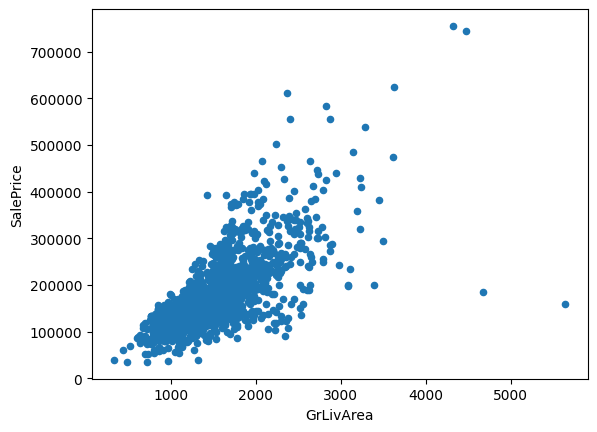

In [10]:
train.plot.scatter(x='GrLivArea', y='SalePrice')

/tmp/ipykernel_262/1032586633.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 1.0, 'GrLivArea vs SalePrice')

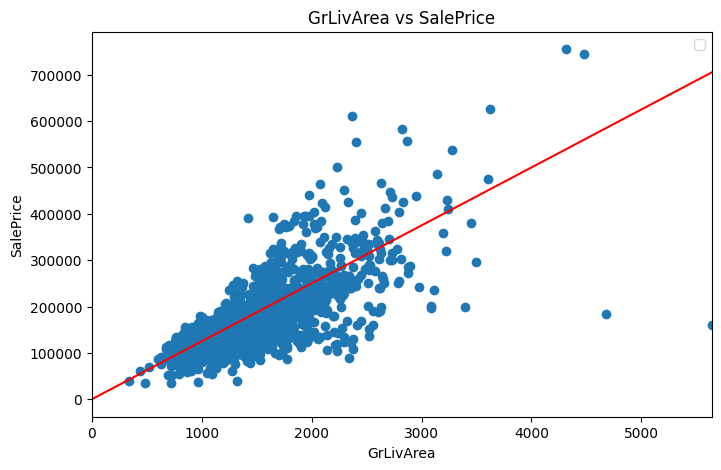

In [11]:
# Definir parametros
m=125
b=0

# Graficar recta
x=np.linspace(0, train['GrLivArea'].max(),100)
y=m*x+b
# Graficar datos y recta
plt.figure(figsize=(8,5))
plt.scatter(train['GrLivArea'],train['SalePrice'])
plt.plot(x,y,color='red')
plt.xlim(0, train['SalePrice'].max())
plt.xlim(0, train['GrLivArea'].max())
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.legend()
plt.title('GrLivArea vs SalePrice')

In [12]:
# Si escogemos esos parámetros
# Hacemos calculo de predicciones y guardamos como nueva columna

train['predd']=train['GrLivArea']*m+b

In [13]:
# Calculamos el error cuadrático
train['diff']=train['predd']-train['SalePrice']
train['cuad']=train['diff']**2

train[['GrLivArea','SalePrice','predd','diff','cuad']].head(3)

,GrLivArea,SalePrice,predd,diff,cuad
0,1710,208500,213750,5250,27562500
1,1262,181500,157750,-23750,564062500
2,1786,223500,223250,-250,62500


In [14]:
# Elegir parámetros que minimicen el error
# Basado en m , b=0

m_grid=np.linspace(50,200,50)# genera 50 puntos entre 50 y 200
grid_error=pd.DataFrame(m_grid,columns=['m'])
grid_error.head()

,m
0,50.000000
1,53.061224
2,56.122449
3,59.183673
4,62.244898


In [15]:
# Codigo que recibe un valor de m
# Devuelve el MSE
# Lo mismo de hace rato de valor cuadrático pero en funcion
def sum_error(m, train_df):
  b=0
  predd=train_df['GrLivArea']*m+b
  diff=predd-train_df['SalePrice']
  caud=diff**2
  mse=caud.mean()
  return mse

In [16]:
# Aplicamos la función
grid_error['error']=grid_error['m'].apply(lambda x: sum_error(x,train))
grid_error.head()

,m,error
0,50.000000,1.509658e+10
1,53.061224,1.404857e+10
2,56.122449,1.304878e+10
3,59.183673,1.209720e+10
4,62.244898,1.119384e+10


In [17]:
indice_minimo=grid_error['error'].idxmin()
min_row=grid_error.loc[indice_minimo]
best_w=min_row['m']
best_error=min_row['error']
# Linea corregida
print(f"El mejor m encontrado :{best_w}")
print(f"El mejor error encontrado :{best_error:.2f}")

El mejor m encontrado :117.3469387755102
El mejor error encontrado :3178169911.80


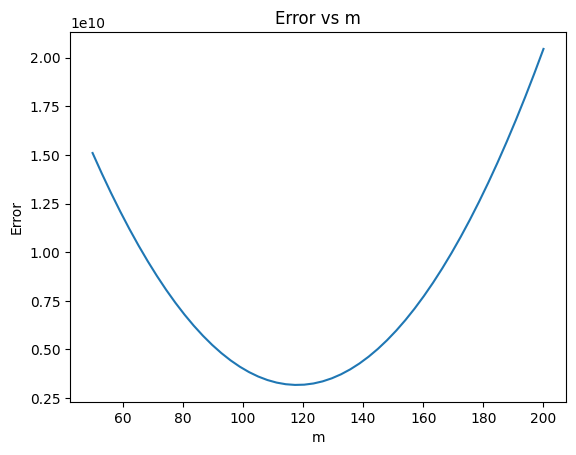

In [18]:
# Grafica
plt.plot(grid_error['m'],grid_error['error'])
plt.xlabel('m')
plt.ylabel('Error')
plt.title('Error vs m')
plt.show()

In [19]:
m_optimo=117
b_optimo=0
def predict(gr_liv_area):
  return m_optimo*gr_liv_area+b_optimo
nueva_area=2000
precio_predicho=predict(nueva_area)
print(f"Predicción para una casa de {nueva_area}: $ {precio_predicho:.2f}")

Predicción para una casa de 2000: $ 234000.00
